In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import re
from math import radians, sin, cos, sqrt, atan2
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 1. 购房数据集

# 1.1.读取数据

# 1.1.1 购房训练集数据读取
df_price_train = pd.read_excel(r"D:\desktop\Midterm\ruc_Class25Q2_train_price.xlsx")
print(f"购房训练集数据读取成功！形状: {df_price_train.shape}")

# 购房训练集基本信息
print("\n=== 购房训练集基本信息 ===")
print(df_price_train.info())
print("\n=== 购房训练集描述统计 ===")
print(df_price_train.describe())
print("\n=== 购房训练集前3行数据 ===")
print(df_price_train.head(3))

# 1.1.2 购房测试集数据读取
df_price_test = pd.read_excel(r"D:\desktop\Midterm\ruc_Class25Q2_test_price.xlsx")
print(f"\n购房测试集数据读取成功！形状: {df_price_test.shape}")

# 购房测试集基本信息
print("\n=== 购房测试集基本信息 ===")
print(df_price_test.info())
print("\n=== 购房测试集描述统计 ===")
print(df_price_test.describe())
print("\n=== 购房测试集前3行数据 ===")
print(df_price_test.head(3))

购房训练集数据读取成功！形状: (103871, 55)

=== 购房训练集基本信息 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103871 entries, 0 to 103870
Data columns (total 55 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   城市         103871 non-null  int64         
 1   区域         103871 non-null  int64         
 2   板块         103871 non-null  int64         
 3   环线         40419 non-null   object        
 4   Price      103871 non-null  float64       
 5   房屋户型       103291 non-null  object        
 6   所在楼层       103871 non-null  object        
 7   建筑面积       103871 non-null  object        
 8   套内面积       35984 non-null   object        
 9   房屋朝向       103870 non-null  object        
 10  建筑结构       103291 non-null  object        
 11  装修情况       103291 non-null  object        
 12  梯户比例       101252 non-null  object        
 13  配备电梯       91520 non-null   object        
 14  别墅类型       1443 non-null    object        
 15  交易时间       103871 no

购房训练集价格统计对比:
原始价格: count    1.038710e+05
mean     2.262366e+06
std      2.532925e+06
min      7.455330e+04
25%      8.910913e+05
50%      1.479407e+06
75%      2.680757e+06
max      5.622643e+07
Name: Price, dtype: float64
对数价格: count    103871.000000
mean         14.262815
std           0.830043
min          11.219270
25%          13.700202
50%          14.207152
75%          14.801610
max          17.844898
Name: lnPrice, dtype: float64
非正价格数量: 0


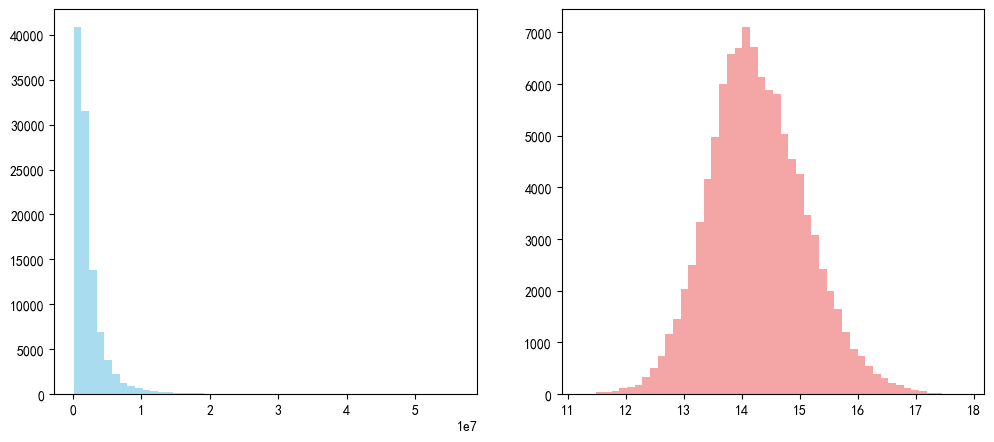

In [3]:
# 1.2.1 价格变量处理（仅训练集）
df_price_train['lnPrice'] = np.log(df_price_train['Price'])

print("购房训练集价格统计对比:")
print("原始价格:", df_price_train['Price'].describe())
print("对数价格:", df_price_train['lnPrice'].describe())

negative_count = len(df_price_train[df_price_train['Price'] <= 0])
print(f"非正价格数量: {negative_count}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(df_price_train['Price'], bins=50, alpha=0.7, color='skyblue')
ax2.hist(df_price_train['lnPrice'], bins=50, alpha=0.7, color='lightcoral')
plt.show()

In [4]:
# 1.2.2 装修变量处理（购房训练集和测试集）

def process_decoration_variables(df, dataset_name=""):
    """处理装修变量，创建哑变量并确保数据类型正确"""
    if dataset_name:
        print(f"{dataset_name}装修情况分布:")
    else:
        print("装修情况分布:")
    
    print(df['装修情况'].value_counts())
    print(f"缺失值: {df['装修情况'].isna().sum()}")

    # 删除已存在的装修哑变量列
    decoration_columns_to_drop = [col for col in df.columns if col.startswith('decoration_')]
    df = df.drop(columns=decoration_columns_to_drop)

    # 定义所有可能的装修类型
    all_decoration_types = ['精装', '简装', '毛坯', '其他']

    # 创建哑变量
    decoration_dummies = pd.get_dummies(df['装修情况'], prefix='decoration')

    # 确保包含所有装修类型（即使某些类型没有数据）
    for deco_type in all_decoration_types:
        col_name = f"decoration_{deco_type}"
        if col_name not in decoration_dummies.columns:
            decoration_dummies[col_name] = 0

    # 按正确的顺序排列列
    decoration_dummies = decoration_dummies.reindex(
        columns=[f"decoration_{deco_type}" for deco_type in all_decoration_types]
    )

    # 将布尔值转换为浮点数 (True/False -> 1.0/0.0)
    decoration_dummies = decoration_dummies.astype(float)

    # 将原始数据中的缺失值反映到哑变量中
    if df['装修情况'].isna().any():
        na_mask = df['装修情况'].isna()
        for col in decoration_dummies.columns:
            decoration_dummies.loc[na_mask, col] = np.nan

    # 将哑变量合并到原数据框
    df = pd.concat([df, decoration_dummies], axis=1)

    # 打印结果
    decoration_dummy_columns = [col for col in df.columns if col.startswith('decoration_')]
    print(f"\n已创建的装修情况哑变量: {decoration_dummy_columns}")

    print("\n装修情况哑变量分布:")
    for col in decoration_dummy_columns:
        valid_count = df[col].notna().sum()
        true_count = (df[col] == 1).sum()
        na_count = df[col].isna().sum()
        print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

    print("装修情况哑变量创建完成（保留缺失值）")
    return df

# 处理购房训练集
df_price_train = process_decoration_variables(df_price_train, "购房训练集")

# 处理购房测试集
df_price_test = process_decoration_variables(df_price_test, "购房测试集")

购房训练集装修情况分布:
装修情况
精装    46585
其他    23820
简装    20522
毛坯    12364
Name: count, dtype: int64
缺失值: 580

已创建的装修情况哑变量: ['decoration_精装', 'decoration_简装', 'decoration_毛坯', 'decoration_其他']

装修情况哑变量分布:
decoration_精装: 46585个为1, 56706个为0, 580个缺失
decoration_简装: 20522个为1, 82769个为0, 580个缺失
decoration_毛坯: 12364个为1, 90927个为0, 580个缺失
decoration_其他: 23820个为1, 79471个为0, 580个缺失
装修情况哑变量创建完成（保留缺失值）
购房测试集装修情况分布:
装修情况
精装    15971
简装     7988
其他     7134
毛坯     2910
Name: count, dtype: int64
缺失值: 14

已创建的装修情况哑变量: ['decoration_精装', 'decoration_简装', 'decoration_毛坯', 'decoration_其他']

装修情况哑变量分布:
decoration_精装: 15971个为1, 18032个为0, 14个缺失
decoration_简装: 7988个为1, 26015个为0, 14个缺失
decoration_毛坯: 2910个为1, 31093个为0, 14个缺失
decoration_其他: 7134个为1, 26869个为0, 14个缺失
装修情况哑变量创建完成（保留缺失值）


In [5]:
# 1.2.3 楼层变量处理（购房训练集和测试集）
def process_floor_features(df):
    df = df.copy()
    
    # 提取总楼层
    df['总楼层'] = df['所在楼层'].str.extract(r'共(\d+)层').astype(float)
    
    # 计算准确楼层
    def get_actual_floor(floor_str, total_floor):
        if pd.isna(total_floor):
            return np.nan
        if '底层' in floor_str:
            return 1
        elif '顶层' in floor_str:
            return total_floor
        elif '地下室' in floor_str:
            return -1
        elif '中楼层' in floor_str:
            return total_floor // 2
        elif '高楼层' in floor_str:
            return int(total_floor * 0.75)
        elif '低楼层' in floor_str:
            return int(total_floor * 0.25)
        else:
            return np.nan
    
    df['准确楼层'] = df.apply(lambda x: get_actual_floor(x['所在楼层'], x['总楼层']), axis=1)
    return df

# 处理购房训练集
df_price_train = process_floor_features(df_price_train)
print("购房训练集楼层变量统计:")
print("总楼层:", df_price_train['总楼层'].describe())
print("准确楼层:", df_price_train['准确楼层'].describe())

# 处理购房测试集
df_price_test = process_floor_features(df_price_test)
print("\n购房测试集楼层变量统计:")
print("总楼层:", df_price_test['总楼层'].describe())
print("准确楼层:", df_price_test['准确楼层'].describe())

购房训练集楼层变量统计:
总楼层: count    103871.000000
mean         18.272184
std          10.983698
min           0.000000
25%           7.000000
50%          18.000000
75%          28.000000
max          70.000000
Name: 总楼层, dtype: float64
准确楼层: count    103871.000000
mean          8.861415
std           7.022439
min          -1.000000
25%           4.000000
50%           7.000000
75%          13.000000
max          43.000000
Name: 准确楼层, dtype: float64

购房测试集楼层变量统计:
总楼层: count    34017.000000
mean        17.474322
std         10.797705
min          0.000000
25%          6.000000
50%         17.000000
75%         27.000000
max         58.000000
Name: 总楼层, dtype: float64
准确楼层: count    34017.000000
mean         8.594232
std          6.850400
min         -1.000000
25%          3.000000
50%          6.000000
75%         13.000000
max         43.000000
Name: 准确楼层, dtype: float64


In [6]:
# 1.2.4 面积变量处理（购房训练集和测试集）
# 处理购房训练集
df_price_train['area'] = df_price_train['建筑面积'].str.replace('㎡', '').astype(float)
print("购房训练集面积提取完成")

# 处理购房测试集
df_price_test['area'] = df_price_test['建筑面积'].str.replace('㎡', '').astype(float)
print("购房测试集面积提取完成")

购房训练集面积提取完成
购房测试集面积提取完成


In [7]:
# 1.2.5 户型变量处理（购房训练集和测试集）
def extract_room_features(df, layout_column='房屋户型'):
    df = df.copy()
    df['室'] = df[layout_column].str.extract(r'(\d+)室').fillna(0).astype(int)
    df['厅'] = df[layout_column].str.extract(r'(\d+)厅').fillna(0).astype(int)
    df['厨'] = df[layout_column].str.extract(r'(\d+)厨').fillna(0).astype(int)
    df['卫'] = df[layout_column].str.extract(r'(\d+)卫').fillna(0).astype(int)
    return df

# 处理购房训练集
df_price_train = extract_room_features(df_price_train)
print("购房训练集户型变量统计:")
for col in ['室', '厅', '厨', '卫']:
    print(f"{col}: {df_price_train[col].describe()}")

# 处理购房测试集
df_price_test = extract_room_features(df_price_test)
print("\n购房测试集户型变量统计:")
for col in ['室', '厅', '厨', '卫']:
    print(f"{col}: {df_price_test[col].describe()}")

购房训练集户型变量统计:
室: count    103871.000000
mean          2.580547
std           1.022637
min           0.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          17.000000
Name: 室, dtype: float64
厅: count    103871.000000
mean          1.509055
std           0.598345
min           0.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           9.000000
Name: 厅, dtype: float64
厨: count    103871.000000
mean          0.986734
std           0.183662
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           7.000000
Name: 厨, dtype: float64
卫: count    103871.000000
mean          1.432065
std           0.668786
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          12.000000
Name: 卫, dtype: float64

购房测试集户型变量统计:
室: count    34017.000000
mean         2.526413
std          0.893239
min          0.000000
25%          2.000000
50%          3.0

In [8]:
# 1.2.6 朝向变量处理（购房训练集和测试集）

def process_orientation_variables(df, dataset_name=""):
    """处理朝向变量，创建哑变量并确保数据类型正确"""
    if dataset_name:
        print(f"{dataset_name}朝向分布:")
    else:
        print("朝向分布:")
    
    print(df['房屋朝向'].value_counts())
    print(f"缺失值: {df['房屋朝向'].isna().sum()}")

    # 删除已存在的朝向哑变量列
    orientation_columns_to_drop = [col for col in df.columns if col in ['south_dummy', 'north_south_dummy']]
    df = df.drop(columns=orientation_columns_to_drop)

    # 初始化朝向哑变量为NaN
    df['south_dummy'] = np.nan
    df['north_south_dummy'] = np.nan

    # 只对非空朝向进行处理
    valid_mask = df['房屋朝向'].notna()
    orientation_str = df.loc[valid_mask, '房屋朝向'].astype(str)

    # 创建朝南哑变量 - 只要包含"南"字就算朝南
    south_mask = orientation_str.str.contains('南')
    df.loc[valid_mask & south_mask, 'south_dummy'] = 1.0
    df.loc[valid_mask & ~south_mask, 'south_dummy'] = 0.0

    # 创建南北通透哑变量 - 同时包含"南"和"北"字
    north_south_mask = orientation_str.str.contains('南') & orientation_str.str.contains('北')
    df.loc[valid_mask & north_south_mask, 'north_south_dummy'] = 1.0
    df.loc[valid_mask & ~north_south_mask, 'north_south_dummy'] = 0.0

    # 打印结果
    print(f"\n{dataset_name}朝向哑变量分布:")
    print(f"朝南: {(df['south_dummy'] == 1.0).sum()}")
    print(f"南北通透: {(df['north_south_dummy'] == 1.0).sum()}")
    
    return df

# 处理购房训练集
df_price_train = process_orientation_variables(df_price_train, "购房训练集")

# 处理购房测试集
df_price_test = process_orientation_variables(df_price_test, "购房测试集")

购房训练集朝向分布:
房屋朝向
南           40475
南 北         24032
东南          12233
东            5279
北            4963
            ...  
南 西 北 东         1
东 北 西 东北        1
北 西 西北          1
东 东南 西          1
东 南 北 东北        1
Name: count, Length: 173, dtype: int64
缺失值: 1

购房训练集朝向哑变量分布:
朝南: 85394
南北通透: 26215
购房测试集朝向分布:
房屋朝向
南              13239
南 北             9887
东南              3305
东               1250
西南              1212
               ...  
东 南 北 东南 东北        1
南 东南 北             1
东南 东 西北 西          1
东 南 东北             1
南 北 东南 西南          1
Name: count, Length: 119, dtype: int64
缺失值: 0

购房测试集朝向哑变量分布:
朝南: 29313
南北通透: 10682


In [9]:
# 1.2.7 交易时间变量处理（购房训练集和测试集）
def process_transaction_date(df):
    df = df.copy()
    df['交易时间'] = pd.to_datetime(df['交易时间'], errors='coerce')
    df['交易年份'] = df['交易时间'].dt.year.astype(float)
    df['交易月份'] = df['交易时间'].dt.month.astype(float)
    df['交易日'] = df['交易时间'].dt.day.astype(float)
    return df

# 处理购房训练集
df_price_train = process_transaction_date(df_price_train)
print("购房训练集交易时间变量统计:")
for col in ['交易年份', '交易月份', '交易日']:
    print(f"{col}: {df_price_train[col].describe()}")

# 处理购房测试集
df_price_test = process_transaction_date(df_price_test)
print("\n购房测试集交易时间变量统计:")
for col in ['交易年份', '交易月份', '交易日']:
    print(f"{col}: {df_price_test[col].describe()}")

购房训练集交易时间变量统计:
交易年份: count    103871.000000
mean       2023.728760
std           0.750136
min        2018.000000
25%        2023.000000
50%        2024.000000
75%        2024.000000
max        2025.000000
Name: 交易年份, dtype: float64
交易月份: count    103871.000000
mean          6.884876
std           3.628327
min           1.000000
25%           4.000000
50%           7.000000
75%          10.000000
max          12.000000
Name: 交易月份, dtype: float64
交易日: count    103871.000000
mean         15.726536
std           8.660784
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          31.000000
Name: 交易日, dtype: float64

购房测试集交易时间变量统计:
交易年份: count    34017.0
mean      2025.0
std          0.0
min       2025.0
25%       2025.0
50%       2025.0
75%       2025.0
max       2025.0
Name: 交易年份, dtype: float64
交易月份: count    34017.000000
mean         4.406297
std          2.838302
min          1.000000
25%          2.000000
50%          4.000000
75%          

In [10]:
# 1.2.8 建筑结构变量处理（购房训练集和测试集）

def process_structure_variables(df, dataset_name=""):
    """处理建筑结构变量，创建哑变量并确保数据类型正确"""
    if dataset_name:
        print(f"{dataset_name}建筑结构分布:")
    else:
        print("建筑结构分布:")
    
    print(df['建筑结构'].value_counts())
    print(f"缺失值: {df['建筑结构'].isna().sum()}")

    # 删除已存在的建筑结构哑变量列
    structure_columns_to_drop = [col for col in df.columns if col.startswith('structure_')]
    df = df.drop(columns=structure_columns_to_drop)

    # 创建建筑结构到英文的映射字典
    structure_mapping = {
        '钢混结构': 'steel_concrete', 
        '混合结构': 'mixed', 
        '未知结构': 'unknown',
        '砖混结构': 'brick_concrete', 
        '框架结构': 'frame', 
        '钢结构': 'steel', 
        '砖木结构': 'brick_wood'
    }

    # 将建筑结构转换为英文并创建哑变量
    df['structure_type_en'] = df['建筑结构'].map(structure_mapping)
    structure_dummies = pd.get_dummies(df['structure_type_en'], prefix='structure')
    
    # 将布尔值转换为浮点数
    structure_dummies = structure_dummies.astype(float)

    # 将原始数据中的缺失值反映到哑变量中
    if df['建筑结构'].isna().any():
        na_mask = df['建筑结构'].isna()
        for col in structure_dummies.columns:
            structure_dummies.loc[na_mask, col] = np.nan

    # 将哑变量合并到原数据框并删除中间列
    df = pd.concat([df, structure_dummies], axis=1)
    df = df.drop('structure_type_en', axis=1)

    # 打印结果
    structure_dummy_columns = [col for col in df.columns if col.startswith('structure_')]
    print(f"\n{dataset_name}建筑结构哑变量分布:")
    for col in structure_dummy_columns:
        valid_count = df[col].notna().sum()
        true_count = (df[col] == 1.0).sum()
        na_count = df[col].isna().sum()
        print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

    return df

# 处理购房训练集
df_price_train = process_structure_variables(df_price_train, "购房训练集")

# 处理购房测试集
df_price_test = process_structure_variables(df_price_test, "购房测试集")

购房训练集建筑结构分布:
建筑结构
钢混结构    82519
混合结构     8971
未知结构     4808
砖混结构     4201
框架结构     1676
钢结构      1066
砖木结构       50
Name: count, dtype: int64
缺失值: 580

购房训练集建筑结构哑变量分布:
structure_brick_concrete: 4201个为1, 99090个为0, 580个缺失
structure_brick_wood: 50个为1, 103241个为0, 580个缺失
structure_frame: 1676个为1, 101615个为0, 580个缺失
structure_mixed: 8971个为1, 94320个为0, 580个缺失
structure_steel: 1066个为1, 102225个为0, 580个缺失
structure_steel_concrete: 82519个为1, 20772个为0, 580个缺失
structure_unknown: 4808个为1, 98483个为0, 580个缺失
购房测试集建筑结构分布:
建筑结构
钢混结构    25065
混合结构     3460
砖混结构     2715
未知结构     1846
框架结构      651
钢结构       230
砖木结构       36
Name: count, dtype: int64
缺失值: 14

购房测试集建筑结构哑变量分布:
structure_brick_concrete: 2715个为1, 31288个为0, 14个缺失
structure_brick_wood: 36个为1, 33967个为0, 14个缺失
structure_frame: 651个为1, 33352个为0, 14个缺失
structure_mixed: 3460个为1, 30543个为0, 14个缺失
structure_steel: 230个为1, 33773个为0, 14个缺失
structure_steel_concrete: 25065个为1, 8938个为0, 14个缺失
structure_unknown: 1846个为1, 32157个为0, 14个缺失


In [11]:
# 1.2.9 梯户比例处理（购房训练集和测试集）
def process_elevator_ratio(df):
    df = df.copy()
    
    chinese_to_num = {
        '一': 1, '两': 2, '二': 2, '三': 3, '四': 4, '五': 5,
        '六': 6, '七': 7, '八': 8, '九': 9, '十': 10,
        '十一': 11, '十二': 12, '十三': 13, '十四': 14, '十五': 15
    }
    
    def split_ratio(ratio_str):
        if pd.isna(ratio_str) or not isinstance(ratio_str, str):
            return None, None
        try:
            ladder_idx = ratio_str.find('梯')
            household_idx = ratio_str.find('户')
            if ladder_idx == -1 or household_idx == -1:
                return None, None
            return (
                chinese_to_num.get(ratio_str[:ladder_idx]),
                chinese_to_num.get(ratio_str[ladder_idx+1:household_idx])
            )
        except:
            return None, None
    
    df['梯数'] = df['梯户比例'].apply(lambda x: split_ratio(x)[0])
    df['户数'] = df['梯户比例'].apply(lambda x: split_ratio(x)[1])
    df['梯户比例_数值'] = df.apply(
        lambda x: x['梯数'] / x['户数'] if pd.notna(x['梯数']) and pd.notna(x['户数']) and x['户数'] > 0 else None, 
        axis=1
    )
    return df

# 处理购房训练集
df_price_train = process_elevator_ratio(df_price_train)
print("购房训练集梯户比例变量统计:")
for col in ['梯数', '户数', '梯户比例_数值']:
    print(f"{col}: {df_price_train[col].describe()}")

# 处理购房测试集
df_price_test = process_elevator_ratio(df_price_test)
print("\n购房测试集梯户比例变量统计:")
for col in ['梯数', '户数', '梯户比例_数值']:
    print(f"{col}: {df_price_test[col].describe()}")

购房训练集梯户比例变量统计:
梯数: count    101131.000000
mean          1.922872
std           1.111247
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max          15.000000
Name: 梯数, dtype: float64
户数: count    94022.000000
mean         4.728670
std          2.984955
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         15.000000
Name: 户数, dtype: float64
梯户比例_数值: count    93901.000000
mean         0.448824
std          0.247321
min          0.066667
25%          0.333333
50%          0.500000
75%          0.500000
max         12.000000
Name: 梯户比例_数值, dtype: float64

购房测试集梯户比例变量统计:
梯数: count    33348.000000
mean         1.755608
std          0.992704
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         15.000000
Name: 梯数, dtype: float64
户数: count    32029.000000
mean         4.418839
std          2.718004
min          1.000000
25%          2.000000
50%          4.00

In [12]:
# 1.2.10 电梯变量处理（购房训练集和测试集）

def process_elevator_variables(df, dataset_name=""):
    """处理电梯变量，创建哑变量并确保数据类型正确"""
    if dataset_name:
        print(f"{dataset_name}电梯分布:")
    else:
        print("电梯分布:")
    
    print(df['配备电梯'].value_counts())
    print(f"缺失值: {df['配备电梯'].isna().sum()}")

    # 删除已存在的电梯哑变量列
    elevator_columns_to_drop = [col for col in df.columns if col.startswith('elevator_')]
    df = df.drop(columns=elevator_columns_to_drop)

    # 创建电梯哑变量，直接创建为浮点数
    df['elevator_yes'] = df['配备电梯'].map({'无': 0.0, '有': 1.0})

    # 处理缺失值 - 将原始数据中的缺失值反映到哑变量中
    if df['配备电梯'].isna().any():
        na_mask = df['配备电梯'].isna()
        df.loc[na_mask, 'elevator_yes'] = np.nan

    # 打印结果
    print(f"\n{dataset_name}电梯哑变量分布:")
    valid_count = df['elevator_yes'].notna().sum()
    true_count = (df['elevator_yes'] == 1.0).sum()
    false_count = (df['elevator_yes'] == 0.0).sum()
    na_count = df['elevator_yes'].isna().sum()
    print(f"有电梯: {true_count}个")
    print(f"无电梯: {false_count}个")
    print(f"缺失值: {na_count}个")

    return df

# 处理购房训练集
df_price_train = process_elevator_variables(df_price_train, "购房训练集")

# 处理购房测试集
df_price_test = process_elevator_variables(df_price_test, "购房测试集")

购房训练集电梯分布:
配备电梯
有    70830
无    20690
Name: count, dtype: int64
缺失值: 12351

购房训练集电梯哑变量分布:
有电梯: 70830个
无电梯: 20690个
缺失值: 12351个
购房测试集电梯分布:
配备电梯
有    21713
无     8212
Name: count, dtype: int64
缺失值: 4092

购房测试集电梯哑变量分布:
有电梯: 21713个
无电梯: 8212个
缺失值: 4092个


In [13]:
# 1.2.11 交易权属变量处理（购房训练集和测试集）

def process_transaction_variables(df, dataset_name=""):
    """处理交易权属变量，创建哑变量并确保数据类型正确"""
    if dataset_name:
        print(f"{dataset_name}交易权属分布:")
    else:
        print("交易权属分布:")
    
    print(df['交易权属'].value_counts())
    print(f"缺失值: {df['交易权属'].isna().sum()}")

    # 删除已存在的交易权属哑变量列
    transaction_columns_to_drop = [col for col in df.columns if col.startswith('transaction_')]
    df = df.drop(columns=transaction_columns_to_drop)

    # 定义商品房和非商品房的分类
    commercial_properties = ['商品房']
    non_commercial_properties = ['已购公房', '动迁安置房', '二类经济适用房', '房改房', '集资房', '一类经济适用房']

    # 创建交易权属类型映射
    def map_transaction_type(transaction):
        if pd.isna(transaction):
            return None
        elif transaction in commercial_properties:
            return 'commercial'
        elif transaction in non_commercial_properties:
            return 'non_commercial'
        else:
            return 'other'

    # 将交易权属转换为类型并创建哑变量
    df['transaction_type_en'] = df['交易权属'].apply(map_transaction_type)
    transaction_dummies = pd.get_dummies(df['transaction_type_en'], prefix='transaction')
    
    # 将布尔值转换为浮点数
    transaction_dummies = transaction_dummies.astype(float)

    # 将原始数据中的缺失值反映到哑变量中
    if df['交易权属'].isna().any():
        na_mask = df['交易权属'].isna()
        for col in transaction_dummies.columns:
            transaction_dummies.loc[na_mask, col] = np.nan

    # 将哑变量合并到原数据框并删除中间列
    df = pd.concat([df, transaction_dummies], axis=1)
    df = df.drop('transaction_type_en', axis=1)

    # 打印结果
    transaction_dummy_columns = [col for col in df.columns if col.startswith('transaction_')]
    print(f"\n{dataset_name}交易权属哑变量分布:")
    for col in transaction_dummy_columns:
        valid_count = df[col].notna().sum()
        true_count = (df[col] == 1.0).sum()
        na_count = df[col].isna().sum()
        print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

    return df

# 处理购房训练集
df_price_train = process_transaction_variables(df_price_train, "购房训练集")

# 处理购房测试集
df_price_test = process_transaction_variables(df_price_test, "购房测试集")

购房训练集交易权属分布:
交易权属
商品房        98242
已购公房        2173
动迁安置房        540
二类经济适用房      535
房改房          484
集资房          461
一类经济适用房      369
拆迁还建房        308
经济适用房        272
私产           169
央产房          155
限价商品房         94
定向安置房         51
售后公房          17
回迁房            1
Name: count, dtype: int64
缺失值: 0

购房训练集交易权属哑变量分布:
transaction_commercial: 98242个为1, 5629个为0, 0个缺失
transaction_non_commercial: 4562个为1, 99309个为0, 0个缺失
transaction_other: 1067个为1, 102804个为0, 0个缺失
购房测试集交易权属分布:
交易权属
商品房        31161
已购公房        1007
动迁安置房        612
一类经济适用房      225
二类经济适用房      215
房改房          168
集资房          152
央产房          143
限价商品房         93
拆迁还建房         62
经济适用房         54
定向安置房         52
私产            40
售后公房          26
自住型商品房         7
Name: count, dtype: int64
缺失值: 0

购房测试集交易权属哑变量分布:
transaction_commercial: 31161个为1, 2856个为0, 0个缺失
transaction_non_commercial: 2379个为1, 31638个为0, 0个缺失
transaction_other: 477个为1, 33540个为0, 0个缺失


In [14]:
# 1.2.12 房屋用途变量处理（购房训练集和测试集）

def process_usage_variables(df, dataset_name=""):
    """处理房屋用途变量，创建哑变量并确保数据类型正确"""
    if dataset_name:
        print(f"{dataset_name}房屋用途分布:")
    else:
        print("房屋用途分布:")
    
    print(df['房屋用途'].value_counts())
    print(f"缺失值: {df['房屋用途'].isna().sum()}")

    # 删除已存在的房屋用途哑变量列
    usage_columns_to_drop = [col for col in df.columns if col.startswith('usage_')]
    df = df.drop(columns=usage_columns_to_drop)

    # 创建房屋用途到分类的映射字典
    usage_mapping = {
        '别墅': 'high_end_residential', 
        '花园洋房': 'high_end_residential',
        '普通住宅': 'ordinary_residential', 
        '公寓': 'ordinary_residential',
        '商住两用': 'commercial_residential', 
        '酒店式公寓': 'commercial_residential',
        '商业办公类': 'commercial_office', 
        '写字楼': 'commercial_office'
    }

    # 将房屋用途转换为分类并创建哑变量
    df['usage_type_en'] = df['房屋用途'].map(usage_mapping)
    usage_dummies = pd.get_dummies(df['usage_type_en'], prefix='usage')
    
    # 将布尔值转换为浮点数
    usage_dummies = usage_dummies.astype(float)

    # 将原始数据中的缺失值反映到哑变量中
    if df['房屋用途'].isna().any():
        na_mask = df['房屋用途'].isna()
        for col in usage_dummies.columns:
            usage_dummies.loc[na_mask, col] = np.nan

    # 将哑变量合并到原数据框并删除中间列
    df = pd.concat([df, usage_dummies], axis=1)
    df = df.drop('usage_type_en', axis=1)

    # 打印结果
    usage_dummy_columns = [col for col in df.columns if col.startswith('usage_')]
    print(f"\n{dataset_name}房屋用途哑变量分布:")
    for col in usage_dummy_columns:
        valid_count = df[col].notna().sum()
        true_count = (df[col] == 1.0).sum()
        na_count = df[col].isna().sum()
        print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

    return df

# 处理购房训练集
df_price_train = process_usage_variables(df_price_train, "购房训练集")

# 处理购房测试集
df_price_test = process_usage_variables(df_price_test, "购房测试集")

购房训练集房屋用途分布:
房屋用途
普通住宅      96099
商住两用       3066
别墅         2032
商业办公类      1527
车库          580
公寓          311
商务公寓        144
酒店式公寓        55
公寓/公寓        14
新式里弄         10
商务型公寓         5
公寓/住宅         5
底商            5
写字楼           4
四合院           3
老公寓           3
商业            3
公寓（住宅）        2
住宅式公寓         1
花园洋房          1
Name: count, dtype: int64
缺失值: 1

购房训练集房屋用途哑变量分布:
usage_commercial_office: 1531个为1, 102339个为0, 1个缺失
usage_commercial_residential: 3121个为1, 100749个为0, 1个缺失
usage_high_end_residential: 2033个为1, 101837个为0, 1个缺失
usage_ordinary_residential: 96410个为1, 7460个为0, 1个缺失
购房测试集房屋用途分布:
房屋用途
普通住宅      32979
商住两用        376
别墅          259
商业办公类       250
公寓           78
商务公寓         29
酒店式公寓        16
车库           14
新式里弄          6
公寓/公寓         3
花园洋房          2
公寓（住宅）        1
公寓/住宅         1
商务型公寓         1
老公寓           1
商业            1
Name: count, dtype: int64
缺失值: 0

购房测试集房屋用途哑变量分布:
usage_commercial_office: 250个为1, 33767个为0, 0个缺失
usage_commercial_residential: 

In [15]:
# 1.2.13 房屋年限变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集房屋年限分布:")
print(df_price_train['房屋年限'].value_counts())
print(f"缺失值: {df_price_train['房屋年限'].isna().sum()}")

# 创建购房训练集房屋年限哑变量
house_age_mapping = {
    '满五年': 'over_5_years',
    '满两年': 'over_2_years', 
    '未满两年': 'under_2_years'
}

df_price_train['house_age_type_en'] = df_price_train['房屋年限'].map(house_age_mapping)
# 使用dtype=float确保生成浮点数哑变量
house_age_dummies_train = pd.get_dummies(df_price_train['house_age_type_en'], prefix='house_age', dtype=float)

if df_price_train['房屋年限'].isna().any():
    na_mask = df_price_train['房屋年限'].isna()
    house_age_dummies_train.loc[na_mask] = np.nan

df_price_train = pd.concat([df_price_train, house_age_dummies_train], axis=1)
df_price_train = df_price_train.drop('house_age_type_en', axis=1)

print("\n购房训练集房屋年限哑变量分布:")
for col in house_age_dummies_train.columns:
    print(f"{col}: {(df_price_train[col] == 1.0).sum()}个为1")  # 比较浮点数

# 处理购房测试集
print("\n购房测试集房屋年限分布:")
print(df_price_test['房屋年限'].value_counts())
print(f"缺失值: {df_price_test['房屋年限'].isna().sum()}")

# 创建购房测试集房屋年限哑变量
df_price_test['house_age_type_en'] = df_price_test['房屋年限'].map(house_age_mapping)
# 使用dtype=float确保生成浮点数哑变量
house_age_dummies_test = pd.get_dummies(df_price_test['house_age_type_en'], prefix='house_age', dtype=float)

if df_price_test['房屋年限'].isna().any():
    na_mask = df_price_test['房屋年限'].isna()
    house_age_dummies_test.loc[na_mask] = np.nan

df_price_test = pd.concat([df_price_test, house_age_dummies_test], axis=1)
df_price_test = df_price_test.drop('house_age_type_en', axis=1)

print("\n购房测试集房屋年限哑变量分布:")
for col in house_age_dummies_test.columns:
    print(f"{col}: {(df_price_test[col] == 1.0).sum()}个为1")  # 比较浮点数

购房训练集房屋年限分布:
房屋年限
满五年     34896
满两年     15361
未满两年     9104
Name: count, dtype: int64
缺失值: 44510

购房训练集房屋年限哑变量分布:
house_age_over_2_years: 15361个为1
house_age_over_5_years: 34896个为1
house_age_under_2_years: 9104个为1

购房测试集房屋年限分布:
房屋年限
满五年     15065
满两年      5241
未满两年     2415
Name: count, dtype: int64
缺失值: 11296

购房测试集房屋年限哑变量分布:
house_age_over_2_years: 5241个为1
house_age_over_5_years: 15065个为1
house_age_under_2_years: 2415个为1


In [16]:
# 1.2.14 地铁变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集房屋优势分布:")
print(df_price_train['房屋优势'].value_counts())
print(f"缺失值: {df_price_train['房屋优势'].isna().sum()}")

# 创建购房训练集地铁哑变量
df_price_train['subway'] = df_price_train['房屋优势'].apply(
    lambda x: np.nan if pd.isna(x) else 1 if '地铁' in str(x) else 0
)

print("\n购房训练集地铁哑变量分布:")
print(f"有地铁: {(df_price_train['subway'] == 1).sum()}")
print(f"无地铁: {(df_price_train['subway'] == 0).sum()}")

# 处理购房测试集
print("\n购房测试集房屋优势分布:")
print(df_price_test['房屋优势'].value_counts())
print(f"缺失值: {df_price_test['房屋优势'].isna().sum()}")

# 创建购房测试集地铁哑变量
df_price_test['subway'] = df_price_test['房屋优势'].apply(
    lambda x: np.nan if pd.isna(x) else 1 if '地铁' in str(x) else 0
)

print("\n购房测试集地铁哑变量分布:")
print(f"有地铁: {(df_price_test['subway'] == 1).sum()}")
print(f"无地铁: {(df_price_test['subway'] == 0).sum()}")

购房训练集房屋优势分布:
房屋优势
装修              9429
地铁、房本满五年        6745
装修、房本满五年        6128
装修、             5542
地铁、装修、房本满五年     5065
地铁、             4818
、房本满五年          4492
、               3857
房本满五年           3782
地铁、装修           3171
地铁              3117
装修、房本满五年、       2873
装修、房本满两年        2462
地铁、房本满两年        2278
装修、房本满两年、       2163
地铁、装修、房本满五年、    2158
房本满两年           1984
地铁、装修、          1879
、房本满五年、         1751
、房本满两年          1716
地铁、房本满五年、       1640
地铁、装修、房本满两年     1479
、房本满两年、         1302
地铁、装修、房本满两年、     972
地铁、房本满两年、        755
房本满五年、           588
房本满两年、           489
Name: count, dtype: int64
缺失值: 21236

购房训练集地铁哑变量分布:
有地铁: 34077
无地铁: 48558

购房测试集房屋优势分布:
房屋优势
地铁、房本满五年        2307
装修、房本满五年        2201
、房本满五年          2140
、               1876
地铁、装修、房本满五年     1874
装修、房本满五年、       1707
装修、             1587
、房本满五年、         1345
地铁、装修、房本满五年、    1317
装修              1306
地铁、房本满五年、       1164
地铁、             1075
装修、房本满两年、        910
房本满五年            846
、房本满两年、          711
装修、房本满两

In [17]:
# 1.2.15 建筑年代变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集建筑年代分布:")
print(df_price_train['建筑年代'].value_counts())
print(f"缺失值: {df_price_train['建筑年代'].isna().sum()}")

# 创建购房训练集房龄变量
def extract_building_age(building_year_str):
    if pd.isna(building_year_str):
        return np.nan
    building_year_str = str(building_year_str).strip()
    current_year = 2025
    
    try:
        if '年' in building_year_str and '-' not in building_year_str:
            year = int(building_year_str.replace('年', ''))
            return current_year - year
        elif '-' in building_year_str and '年' in building_year_str:
            year_range = building_year_str.replace('年', '').split('-')
            if len(year_range) == 2:
                return current_year - int(year_range[1])
        return np.nan
    except:
        return np.nan

df_price_train['building_age'] = df_price_train['建筑年代'].apply(extract_building_age)

print("\n购房训练集房龄变量统计:")
print(f"building_age: {df_price_train['building_age'].describe()}")

# 处理购房测试集
print("\n购房测试集建筑年代分布:")
print(df_price_test['建筑年代'].value_counts())
print(f"缺失值: {df_price_test['建筑年代'].isna().sum()}")

# 创建购房测试集房龄变量
df_price_test['building_age'] = df_price_test['建筑年代'].apply(extract_building_age)

print("\n购房测试集房龄变量统计:")
print(f"building_age: {df_price_test['building_age'].describe()}")

购房训练集建筑年代分布:
建筑年代
2000-2012年    989
2015-2018年    951
2008-2014年    940
2008年         801
2013-2016年    779
             ... 
1954-1994年      1
1994-2009年      1
1985-1986年      1
1974-1979年      1
2002-2019年      1
Name: count, Length: 736, dtype: int64
缺失值: 35101

购房训练集房龄变量统计:
building_age: count    68770.000000
mean        14.387218
std          7.701892
min          3.000000
25%          8.000000
50%         12.000000
75%         20.000000
max         89.000000
Name: building_age, dtype: float64

购房测试集建筑年代分布:
建筑年代
2000-2012年    343
2015-2018年    303
2000-2018年    292
2018-2019年    290
2006年         288
             ... 
1974-1979年      1
2018-2021年      1
1970-1979年      1
1985-2001年      1
1998-2012年      1
Name: count, Length: 716, dtype: int64
缺失值: 9406

购房测试集房龄变量统计:
building_age: count    24611.000000
mean        15.990614
std          8.521591
min          3.000000
25%          9.000000
50%         15.000000
75%         22.000000
max         89.000000
Name: building_age, dtype

In [18]:
# 1.2.16 小区规模变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集房屋总数分布:")
print(df_price_train['房屋总数'].value_counts().head(5))
print("\n购房训练集楼栋总数分布:")
print(df_price_train['楼栋总数'].value_counts().head(5))

# 创建购房训练集小区规模变量
def extract_number(text):
    if pd.isna(text):
        return np.nan
    match = re.search(r'(\d+)', str(text))
    return int(match.group(1)) if match else np.nan

df_price_train['household_total'] = df_price_train['房屋总数'].apply(extract_number)
df_price_train['building_total'] = df_price_train['楼栋总数'].apply(extract_number)

print("\n购房训练集小区规模变量统计:")
print(f"household_total: {df_price_train['household_total'].describe()}")
print(f"building_total: {df_price_train['building_total'].describe()}")

# 处理购房测试集
print("\n购房测试集房屋总数分布:")
print(df_price_test['房屋总数'].value_counts().head(5))
print("\n购房测试集楼栋总数分布:")
print(df_price_test['楼栋总数'].value_counts().head(5))

# 创建购房测试集小区规模变量
df_price_test['household_total'] = df_price_test['房屋总数'].apply(extract_number)
df_price_test['building_total'] = df_price_test['楼栋总数'].apply(extract_number)

print("\n购房测试集小区规模变量统计:")
print(f"household_total: {df_price_test['household_total'].describe()}")
print(f"building_total: {df_price_test['building_total'].describe()}")

购房训练集房屋总数分布:
房屋总数
6458户    793
7435户    741
9342户    694
7387户    548
15户      497
Name: count, dtype: int64

购房训练集楼栋总数分布:
楼栋总数
7栋    4295
8栋    3978
4栋    3971
5栋    3929
6栋    3902
Name: count, dtype: int64

购房训练集小区规模变量统计:
household_total: count    96740.000000
mean      1922.226969
std       1868.281271
min          1.000000
25%        679.000000
50%       1372.000000
75%       2504.000000
max      12669.000000
Name: household_total, dtype: float64
building_total: count    96740.000000
mean        30.521925
std         60.900276
min          1.000000
25%          7.000000
50%         15.000000
75%         30.000000
max        734.000000
Name: building_total, dtype: float64

购房测试集房屋总数分布:
房屋总数
10505户    176
7666户     170
5184户     144
9342户     142
6458户     139
Name: count, dtype: int64

购房测试集楼栋总数分布:
楼栋总数
10栋    1169
7栋     1151
5栋     1093
6栋     1068
8栋     1013
Name: count, dtype: int64

购房测试集小区规模变量统计:
household_total: count    30302.000000
mean      1962.300442
std       1924.483

In [19]:
# 1.2.17 绿化率和容积率变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集绿化率分布:")
print(df_price_train['绿化率'].value_counts().head(5))
print("\n购房训练集容积率分布:")
print(df_price_train['容积率'].value_counts().head(5))

# 创建购房训练集绿化率和容积率变量
df_price_train['greening_rate'] = df_price_train['绿化率'].astype(str).str.replace('%', '').astype(float) / 100
df_price_train['plot_ratio'] = df_price_train['容积率'].astype(float)

print("\n购房训练集绿化率和容积率统计:")
print(f"greening_rate: {df_price_train['greening_rate'].describe()}")
print(f"plot_ratio: {df_price_train['plot_ratio'].describe()}")

# 处理购房测试集
print("\n购房测试集绿化率分布:")
print(df_price_test['绿化率'].value_counts().head(5))
print("\n购房测试集容积率分布:")
print(df_price_test['容积率'].value_counts().head(5))

# 创建购房测试集绿化率和容积率变量
df_price_test['greening_rate'] = df_price_test['绿化率'].astype(str).str.replace('%', '').astype(float) / 100
df_price_test['plot_ratio'] = df_price_test['容积率'].astype(float)

print("\n购房测试集绿化率和容积率统计:")
print(f"greening_rate: {df_price_test['greening_rate'].describe()}")
print(f"plot_ratio: {df_price_test['plot_ratio'].describe()}")

购房训练集绿化率分布:
绿化率
0.30    20218
0.35    16259
0.40     5155
0.45     2873
0.20     2545
Name: count, dtype: int64

购房训练集容积率分布:
容积率
2.0    6538
2.5    6213
3.0    5596
1.5    2871
1.0    1666
Name: count, dtype: int64

购房训练集绿化率和容积率统计:
greening_rate: count    70988.000000
mean         0.004026
std          0.027225
min          0.000001
25%          0.003000
50%          0.003400
75%          0.003600
max          1.050000
Name: greening_rate, dtype: float64
plot_ratio: count    70717.000000
mean         2.780097
std          1.607581
min          0.020000
25%          1.800000
50%          2.500000
75%          3.200000
max         30.000000
Name: plot_ratio, dtype: float64

购房测试集绿化率分布:
绿化率
0.30    6594
0.35    6243
0.40    1973
0.45     961
0.20     893
Name: count, dtype: int64

购房测试集容积率分布:
容积率
2.0    2555
2.5    2007
3.0    1742
1.5     969
1.8     738
Name: count, dtype: int64

购房测试集绿化率和容积率统计:
greening_rate: count    24837.000000
mean         0.003736
std          0.021019
min        

In [20]:
# 1.2.18 物业费变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集物业费分布:")
print(df_price_train['物业费'].value_counts().head(5))

def extract_property_fee(property_fee_str):
    if pd.isna(property_fee_str):
        return np.nan
    property_fee_str = str(property_fee_str).strip()
    
    # 提取所有数字
    numbers = re.findall(r'\d+\.?\d*', property_fee_str)
    if len(numbers) == 1:
        return float(numbers[0])
    elif len(numbers) == 2:
        return (float(numbers[0]) + float(numbers[1])) / 2
    else:
        return np.nan

df_price_train['property_fee_avg'] = df_price_train['物业费'].apply(extract_property_fee)

print("\n购房训练集物业费变量统计:")
print(f"property_fee_avg: {df_price_train['property_fee_avg'].describe()}")

# 处理购房测试集
print("\n购房测试集物业费分布:")
print(df_price_test['物业费'].value_counts().head(5))

df_price_test['property_fee_avg'] = df_price_test['物业费'].apply(extract_property_fee)

print("\n购房测试集物业费变量统计:")
print(f"property_fee_avg: {df_price_test['property_fee_avg'].describe()}")

购房训练集物业费分布:
物业费
2.8元/月/㎡    2740
1.2元/月/㎡    2293
1元/月/㎡      2128
1.8元/月/㎡    1906
1.5元/月/㎡    1458
Name: count, dtype: int64

购房训练集物业费变量统计:
property_fee_avg: count    72713.000000
mean         2.570552
std          3.941621
min          0.020000
25%          1.200000
50%          1.900000
75%          2.800000
max         76.450000
Name: property_fee_avg, dtype: float64

购房测试集物业费分布:
物业费
2.8元/月/㎡    916
0.8元/月/㎡    762
1元/月/㎡      730
1.2元/月/㎡    644
1.8元/月/㎡    584
Name: count, dtype: int64

购房测试集物业费变量统计:
property_fee_avg: count    25528.000000
mean         2.408548
std          4.101584
min          0.200000
25%          1.100000
50%          1.760000
75%          2.680000
max         76.450000
Name: property_fee_avg, dtype: float64


In [21]:
# 1.2.19 供水变量处理（购房训练集和测试集）

def process_water_variables(df, dataset_name=""):
    """处理供水变量，创建哑变量并确保数据类型正确"""
    if dataset_name:
        print(f"{dataset_name}供水分布:")
    else:
        print("供水分布:")
    
    print(df['供水'].value_counts())
    print(f"缺失值: {df['供水'].isna().sum()}")

    # 删除已存在的供水哑变量列
    water_columns_to_drop = [col for col in df.columns if col.startswith('water_')]
    df = df.drop(columns=water_columns_to_drop)

    # 创建供水类型到英文的映射字典
    water_supply_mapping = {
        '民水': 'civil_water',
        '商水': 'commercial_water', 
        '商水/民水': 'mixed_water'
    }

    # 将供水类型转换为英文
    df['water_type_en'] = df['供水'].map(water_supply_mapping)

    # 创建民水和商水哑变量，直接创建为浮点数
    df['water_civil'] = df['water_type_en'].isin(['civil_water', 'mixed_water']).astype(float)
    df['water_commercial'] = df['water_type_en'].isin(['commercial_water', 'mixed_water']).astype(float)

    # 处理缺失值 - 将原始数据中的缺失值反映到哑变量中
    if df['供水'].isna().any():
        na_mask = df['供水'].isna()
        df.loc[na_mask, 'water_civil'] = np.nan
        df.loc[na_mask, 'water_commercial'] = np.nan

    # 删除中间列
    df = df.drop('water_type_en', axis=1)

    # 打印结果
    print(f"\n{dataset_name}供水哑变量分布:")
    water_civil_valid = df['water_civil'].notna().sum()
    water_civil_true = (df['water_civil'] == 1.0).sum()
    water_civil_na = df['water_civil'].isna().sum()
    
    water_commercial_valid = df['water_commercial'].notna().sum()
    water_commercial_true = (df['water_commercial'] == 1.0).sum()
    water_commercial_na = df['water_commercial'].isna().sum()
    
    print(f"民水: {water_civil_true}个为1, {water_civil_valid-water_civil_true}个为0, {water_civil_na}个缺失")
    print(f"商水: {water_commercial_true}个为1, {water_commercial_valid-water_commercial_true}个为0, {water_commercial_na}个缺失")

    return df

# 处理购房训练集
df_price_train = process_water_variables(df_price_train, "购房训练集")

# 处理购房测试集
df_price_test = process_water_variables(df_price_test, "购房测试集")

购房训练集供水分布:
供水
民水       47635
商水/民水    25181
商水         757
Name: count, dtype: int64
缺失值: 30298

购房训练集供水哑变量分布:
民水: 72816个为1, 757个为0, 30298个缺失
商水: 25938个为1, 47635个为0, 30298个缺失
购房测试集供水分布:
供水
民水       17886
商水/民水     7777
商水         159
Name: count, dtype: int64
缺失值: 8195

购房测试集供水哑变量分布:
民水: 25663个为1, 159个为0, 8195个缺失
商水: 7936个为1, 17886个为0, 8195个缺失


In [22]:
# 1.2.20 供暖变量处理（购房训练集和测试集）

def process_heating_variables(df, dataset_name=""):
    """处理供暖变量，创建哑变量并确保数据类型正确"""
    if dataset_name:
        print(f"{dataset_name}供暖分布:")
    else:
        print("供暖分布:")
    
    print(df['供暖'].value_counts())
    print(f"缺失值: {df['供暖'].isna().sum()}")

    # 删除已存在的供暖哑变量列
    heating_columns_to_drop = [col for col in df.columns if col.startswith('heating_')]
    df = df.drop(columns=heating_columns_to_drop)

    # 创建供暖类型到英文的映射字典
    heating_mapping = {
        '集中供暖': 'central_heating',
        '自采暖': 'self_heating', 
        '集中供暖/自采暖': 'mixed_heating'
    }

    # 将供暖类型转换为英文
    df['heating_type_en'] = df['供暖'].map(heating_mapping)

    # 创建集中供暖和自采暖哑变量，直接创建为浮点数
    df['heating_central'] = df['heating_type_en'].isin(['central_heating', 'mixed_heating']).astype(float)
    df['heating_self'] = df['heating_type_en'].isin(['self_heating', 'mixed_heating']).astype(float)

    # 处理缺失值 - 将原始数据中的缺失值反映到哑变量中
    if df['供暖'].isna().any():
        na_mask = df['供暖'].isna()
        df.loc[na_mask, 'heating_central'] = np.nan
        df.loc[na_mask, 'heating_self'] = np.nan

    # 删除中间列
    df = df.drop('heating_type_en', axis=1)

    # 打印结果
    print(f"\n{dataset_name}供暖哑变量分布:")
    heating_central_valid = df['heating_central'].notna().sum()
    heating_central_true = (df['heating_central'] == 1.0).sum()
    heating_central_na = df['heating_central'].isna().sum()
    
    heating_self_valid = df['heating_self'].notna().sum()
    heating_self_true = (df['heating_self'] == 1.0).sum()
    heating_self_na = df['heating_self'].isna().sum()
    
    print(f"集中供暖: {heating_central_true}个为1, {heating_central_valid-heating_central_true}个为0, {heating_central_na}个缺失")
    print(f"自采暖: {heating_self_true}个为1, {heating_self_valid-heating_self_true}个为0, {heating_self_na}个缺失")

    return df

# 处理购房训练集
df_price_train = process_heating_variables(df_price_train, "购房训练集")

# 处理购房测试集
df_price_test = process_heating_variables(df_price_test, "购房测试集")

购房训练集供暖分布:
供暖
集中供暖            18547
自采暖              8326
集中供暖/自采暖         3629
无供暖               274
自采暖/无供暖           103
集中供暖/自采暖/无供暖       66
Name: count, dtype: int64
缺失值: 72926

购房训练集供暖哑变量分布:
集中供暖: 22176个为1, 8769个为0, 72926个缺失
自采暖: 11955个为1, 18990个为0, 72926个缺失
购房测试集供暖分布:
供暖
集中供暖            7197
自采暖             6042
集中供暖/自采暖        1752
无供暖              202
集中供暖/自采暖/无供暖     146
自采暖/无供暖           76
Name: count, dtype: int64
缺失值: 18602

购房测试集供暖哑变量分布:
集中供暖: 8949个为1, 6466个为0, 18602个缺失
自采暖: 7794个为1, 7621个为0, 18602个缺失


In [23]:
# 1.2.21 供电变量处理（购房训练集和测试集）

def process_electricity_variables(df, dataset_name=""):
    """处理供电变量，创建哑变量并确保数据类型正确"""
    if dataset_name:
        print(f"{dataset_name}供电分布:")
    else:
        print("供电分布:")
    
    print(df['供电'].value_counts())
    print(f"缺失值: {df['供电'].isna().sum()}")

    # 删除已存在的供电哑变量列
    electricity_columns_to_drop = [col for col in df.columns if col.startswith('electricity_')]
    df = df.drop(columns=electricity_columns_to_drop)

    # 创建供电类型到英文的映射字典
    electricity_mapping = {
        '民电': 'civil_electricity',
        '商电': 'commercial_electricity', 
        '商电/民电': 'mixed_electricity'
    }

    # 将供电类型转换为英文
    df['electricity_type_en'] = df['供电'].map(electricity_mapping)

    # 创建民电和商电哑变量，直接创建为浮点数
    df['electricity_civil'] = df['electricity_type_en'].isin(['civil_electricity', 'mixed_electricity']).astype(float)
    df['electricity_commercial'] = df['electricity_type_en'].isin(['commercial_electricity', 'mixed_electricity']).astype(float)

    # 处理缺失值 - 将原始数据中的缺失值反映到哑变量中
    if df['供电'].isna().any():
        na_mask = df['供电'].isna()
        df.loc[na_mask, 'electricity_civil'] = np.nan
        df.loc[na_mask, 'electricity_commercial'] = np.nan

    # 删除中间列
    df = df.drop('electricity_type_en', axis=1)

    # 打印结果
    print(f"\n{dataset_name}供电哑变量分布:")
    electricity_civil_valid = df['electricity_civil'].notna().sum()
    electricity_civil_true = (df['electricity_civil'] == 1.0).sum()
    electricity_civil_na = df['electricity_civil'].isna().sum()
    
    electricity_commercial_valid = df['electricity_commercial'].notna().sum()
    electricity_commercial_true = (df['electricity_commercial'] == 1.0).sum()
    electricity_commercial_na = df['electricity_commercial'].isna().sum()
    
    print(f"民电: {electricity_civil_true}个为1, {electricity_civil_valid-electricity_civil_true}个为0, {electricity_civil_na}个缺失")
    print(f"商电: {electricity_commercial_true}个为1, {electricity_commercial_valid-electricity_commercial_true}个为0, {electricity_commercial_na}个缺失")

    return df

# 处理购房训练集
df_price_train = process_electricity_variables(df_price_train, "购房训练集")

# 处理购房测试集
df_price_test = process_electricity_variables(df_price_test, "购房测试集")

购房训练集供电分布:
供电
民电       47086
商电/民电    25674
商电         819
Name: count, dtype: int64
缺失值: 30292

购房训练集供电哑变量分布:
民电: 72760个为1, 819个为0, 30292个缺失
商电: 26493个为1, 47086个为0, 30292个缺失
购房测试集供电分布:
供电
民电       17522
商电/民电     8160
商电         158
Name: count, dtype: int64
缺失值: 8177

购房测试集供电哑变量分布:
民电: 25682个为1, 158个为0, 8177个缺失
商电: 8318个为1, 17522个为0, 8177个缺失


In [24]:
# 1.2.22 燃气费变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集燃气费分布:")
print(df_price_train['燃气费'].value_counts().head(5))

def extract_gas_fee(gas_fee_str):
    if pd.isna(gas_fee_str):
        return np.nan
    gas_fee_str = str(gas_fee_str).strip()
    
    # 提取所有数字
    numbers = re.findall(r'\d+\.?\d*', gas_fee_str)
    if len(numbers) == 1:
        return float(numbers[0])
    elif len(numbers) == 2:
        return (float(numbers[0]) + float(numbers[1])) / 2
    else:
        return np.nan

df_price_train['gas_fee_avg'] = df_price_train['燃气费'].apply(extract_gas_fee)

print("\n购房训练集燃气费变量统计:")
print(f"gas_fee_avg: {df_price_train['gas_fee_avg'].describe()}")

# 处理购房测试集
print("\n购房测试集燃气费分布:")
print(df_price_test['燃气费'].value_counts().head(5))

df_price_test['gas_fee_avg'] = df_price_test['燃气费'].apply(extract_gas_fee)

print("\n购房测试集燃气费变量统计:")
print(f"gas_fee_avg: {df_price_test['gas_fee_avg'].describe()}")

购房训练集燃气费分布:
燃气费
2.61元/m³    14390
3.45元/m³    12488
1.98元/m³     8093
1.96元/m³     3378
3元/m³        3285
Name: count, dtype: int64

购房训练集燃气费变量统计:
gas_fee_avg: count    71170.000000
mean         2.683228
std          0.620354
min          0.400000
25%          1.980000
50%          2.610000
75%          3.250000
max          5.000000
Name: gas_fee_avg, dtype: float64

购房测试集燃气费分布:
燃气费
2.61元/m³         6105
3元/m³            4056
3.45元/m³         3074
1.98元/m³         1815
2.61-2.63元/m³     794
Name: count, dtype: int64

购房测试集燃气费变量统计:
gas_fee_avg: count    24860.000000
mean         2.767434
std          0.548511
min          0.400000
25%          2.470000
50%          2.610000
75%          3.000000
max          5.000000
Name: gas_fee_avg, dtype: float64


In [25]:
# 1.2.23 供热费变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集供热费分布:")
print(df_price_train['供热费'].value_counts().head(5))

def extract_heating_fee(heating_fee_str):
    if pd.isna(heating_fee_str):
        return np.nan
    heating_fee_str = str(heating_fee_str).strip()
    
    # 提取所有数字
    numbers = re.findall(r'\d+\.?\d*', heating_fee_str)
    if len(numbers) == 1:
        return float(numbers[0])
    elif len(numbers) == 2:
        return (float(numbers[0]) + float(numbers[1])) / 2
    else:
        return np.nan

df_price_train['heating_fee_avg'] = df_price_train['供热费'].apply(extract_heating_fee)

print("\n购房训练集供热费变量统计:")
print(f"heating_fee_avg: {df_price_train['heating_fee_avg'].describe()}")

# 处理购房测试集
print("\n购房测试集供热费分布:")
print(df_price_test['供热费'].value_counts().head(5))

df_price_test['heating_fee_avg'] = df_price_test['供热费'].apply(extract_heating_fee)

print("\n购房测试集供热费变量统计:")
print(f"heating_fee_avg: {df_price_test['heating_fee_avg'].describe()}")

购房训练集供热费分布:
供热费
30元/㎡       9688
1元/㎡        4734
25元/㎡       1915
24-30元/㎡    1600
24元/㎡       1522
Name: count, dtype: int64

购房训练集供热费变量统计:
heating_fee_avg: count    31383.000000
mean        18.826806
std         12.976055
min          0.010000
25%          2.500000
50%         25.000000
75%         30.000000
max         50.000000
Name: heating_fee_avg, dtype: float64

购房测试集供热费分布:
供热费
30元/㎡       4300
1元/㎡        1109
24-30元/㎡     697
22元/㎡        583
24元/㎡        572
Name: count, dtype: int64

购房测试集供热费变量统计:
heating_fee_avg: count    10989.000000
mean        20.597541
std         12.279816
min          0.010000
25%          5.300000
50%         27.000000
75%         30.000000
max         50.000000
Name: heating_fee_avg, dtype: float64


In [26]:
# 1.2.24 停车位变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集停车位分布:")
print(df_price_train['停车位'].value_counts().head(5))

# 创建购房训练集停车位变量
df_price_train['parking_spots'] = pd.to_numeric(df_price_train['停车位'], errors='coerce')

print("\n购房训练集停车位变量统计:")
print(f"parking_spots: {df_price_train['parking_spots'].describe()}")

# 处理购房测试集
print("\n购房测试集停车位分布:")
print(df_price_test['停车位'].value_counts().head(5))

# 创建购房测试集停车位变量
df_price_test['parking_spots'] = pd.to_numeric(df_price_test['停车位'], errors='coerce')

print("\n购房测试集停车位变量统计:")
print(f"parking_spots: {df_price_test['parking_spots'].describe()}")

购房训练集停车位分布:
停车位
500.0     3214
200.0     2125
300.0     2004
600.0     1617
1000.0    1568
Name: count, dtype: int64

购房训练集停车位变量统计:
parking_spots: count    69303.000000
mean      1158.042264
std       1301.382856
min          1.000000
25%        312.000000
50%        734.000000
75%       1515.000000
max       8700.000000
Name: parking_spots, dtype: float64

购房测试集停车位分布:
停车位
500.0     1072
200.0      854
300.0      776
100.0      643
1000.0     555
Name: count, dtype: int64

购房测试集停车位变量统计:
parking_spots: count    24446.000000
mean      1114.219831
std       1388.954171
min          1.000000
25%        255.000000
50%        650.000000
75%       1495.000000
max       8700.000000
Name: parking_spots, dtype: float64


In [27]:
# 1.2.25 周边配套变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集周边配套分布:")
print(df_price_train['周边配套'].value_counts().head(5))

# 创建购房训练集周边配套哑变量
def check_surrounding_facilities(text):
    if pd.isna(text):
        return []
    text_str = str(text)
    facilities = []
    if re.search(r'医院|医疗|诊所', text_str):
        facilities.append('hospital')
    if re.search(r'大学|学院|高校', text_str):
        facilities.append('university')
    if re.search(r'小学|中学|学校', text_str):
        facilities.append('school')
    if re.search(r'超市|商场|购物', text_str):
        facilities.append('supermarket')
    return facilities

surrounding_facilities_train = df_price_train['周边配套'].apply(check_surrounding_facilities)
# 直接创建浮点数列
df_price_train['surrounding_hospital'] = surrounding_facilities_train.apply(lambda x: 1.0 if 'hospital' in x else 0.0)
df_price_train['surrounding_university'] = surrounding_facilities_train.apply(lambda x: 1.0 if 'university' in x else 0.0)
df_price_train['surrounding_school'] = surrounding_facilities_train.apply(lambda x: 1.0 if 'school' in x else 0.0)
df_price_train['surrounding_supermarket'] = surrounding_facilities_train.apply(lambda x: 1.0 if 'supermarket' in x else 0.0)

print("\n购房训练集周边配套哑变量分布:")
for col in ['surrounding_hospital', 'surrounding_university', 'surrounding_school', 'surrounding_supermarket']:
    print(f"{col}: {(df_price_train[col] == 1.0).sum()}个为1")

# 处理购房测试集
print("\n购房测试集周边配套分布:")
print(df_price_test['周边配套'].value_counts().head(5))

# 创建购房测试集周边配套哑变量
surrounding_facilities_test = df_price_test['周边配套'].apply(check_surrounding_facilities)
# 直接创建浮点数列
df_price_test['surrounding_hospital'] = surrounding_facilities_test.apply(lambda x: 1.0 if 'hospital' in x else 0.0)
df_price_test['surrounding_university'] = surrounding_facilities_test.apply(lambda x: 1.0 if 'university' in x else 0.0)
df_price_test['surrounding_school'] = surrounding_facilities_test.apply(lambda x: 1.0 if 'school' in x else 0.0)
df_price_test['surrounding_supermarket'] = surrounding_facilities_test.apply(lambda x: 1.0 if 'supermarket' in x else 0.0)

print("\n购房测试集周边配套哑变量分布:")
for col in ['surrounding_hospital', 'surrounding_university', 'surrounding_school', 'surrounding_supermarket']:
    print(f"{col}: {(df_price_test[col] == 1.0).sum()}个为1")

购房训练集周边配套分布:
周边配套
南山维拉项目北临甪直大道，西临长虹北路，南临迎宾西路。项目是由南山地产开发的70年产权住宅小区，共由13幢电梯洋房和19幢高层、约3万方维乐城、幼儿园组成；整体占地面积为17万余平米，建筑面积近50万平米                172
小区南门有东贸国际服装城、东贸珠宝城、物美大卖场。小区东侧有中商生活市场、潮白路市场。小区南1公里就是燕达医院和燕达国际健康城疗养基地。小区北侧有东贸名品街，湾仔城天街步行街，小区北侧1公里有星罗城购物，小区东侧1公里有行宫市场    119
位于南滨路滨江沿线，它北临长江，背依南山，楼盘位置处可看到渝中夜景，旁边有巴渝十二景中的海棠烟雨、长嘉汇购物公园、弹子石老街、慈云寺、法国水师兵营、蓝光耍街和美心洋人街，吃喝玩乐、出行游玩都比较方便。                  102
品质小区，绿化好，合数居住，合适已退休人员购买或者上班族购买；因为小区环境好，有公园散步可以，巴滨路边上出行方便。轻轨2个站点在修建当中公交车3路直达九公里南平大坪                                     94
金山国际医院，人和医院，北部新区人民医院。公园配套：5000亩照母山森林公园、3200亩九曲河湿地公园、400亩颐和公园、400亩金渝郊野公园、黄桷生态园、园博园等。生活配套：蓝湖郡体育公园、保利高尔夫球场、川剧院等           93
Name: count, dtype: int64

购房训练集周边配套哑变量分布:
surrounding_hospital: 30512个为1
surrounding_university: 4464个为1
surrounding_school: 504个为1
surrounding_supermarket: 25960个为1

购房测试集周边配套分布:
周边配套
一个地铁线：11号线昌吉东路站2.两大医院：安亭医院、东方肝胆医院3.一大公园：上海汽车博览公园4.三大商场：嘉亭荟大润发广场、底特律财富广场、三德广场                                          53
南山维拉项目北临甪直大道，西临长虹北路，南临迎宾西路。项目是由南山地产开发的70年产权住宅小区，共由13幢电梯洋房和19幢高层、约

In [28]:
# 1.2.26 建筑结构变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集建筑结构分布:")
print(df_price_train['建筑结构'].value_counts())

# 创建购房训练集建筑结构哑变量
structure_material_mapping = {
    '钢混结构': 'steel_concrete', '混合结构': 'mixed', '未知结构': 'unknown',
    '砖混结构': 'brick_concrete', '框架结构': 'frame', '钢结构': 'steel', '砖木结构': 'brick_wood'
}

df_price_train['structure_material_type_en'] = df_price_train['建筑结构'].map(structure_material_mapping)
# 使用dtype=float确保生成浮点数哑变量
structure_material_dummies_train = pd.get_dummies(df_price_train['structure_material_type_en'], prefix='structure_material', dtype=float)

if df_price_train['建筑结构'].isna().any():
    na_mask = df_price_train['建筑结构'].isna()
    structure_material_dummies_train.loc[na_mask] = np.nan

df_price_train = pd.concat([df_price_train, structure_material_dummies_train], axis=1)
df_price_train = df_price_train.drop('structure_material_type_en', axis=1)

print("\n购房训练集建筑结构哑变量分布:")
for col in structure_material_dummies_train.columns:
    print(f"{col}: {(df_price_train[col] == 1.0).sum()}个为1")

# 处理购房测试集
print("\n购房测试集建筑结构分布:")
print(df_price_test['建筑结构'].value_counts())

# 创建购房测试集建筑结构哑变量
df_price_test['structure_material_type_en'] = df_price_test['建筑结构'].map(structure_material_mapping)
# 使用dtype=float确保生成浮点数哑变量
structure_material_dummies_test = pd.get_dummies(df_price_test['structure_material_type_en'], prefix='structure_material', dtype=float)

if df_price_test['建筑结构'].isna().any():
    na_mask = df_price_test['建筑结构'].isna()
    structure_material_dummies_test.loc[na_mask] = np.nan

df_price_test = pd.concat([df_price_test, structure_material_dummies_test], axis=1)
df_price_test = df_price_test.drop('structure_material_type_en', axis=1)

print("\n购房测试集建筑结构哑变量分布:")
for col in structure_material_dummies_test.columns:
    print(f"{col}: {(df_price_test[col] == 1.0).sum()}个为1")

购房训练集建筑结构分布:
建筑结构
钢混结构    82519
混合结构     8971
未知结构     4808
砖混结构     4201
框架结构     1676
钢结构      1066
砖木结构       50
Name: count, dtype: int64

购房训练集建筑结构哑变量分布:
structure_material_brick_concrete: 4201个为1
structure_material_brick_wood: 50个为1
structure_material_frame: 1676个为1
structure_material_mixed: 8971个为1
structure_material_steel: 1066个为1
structure_material_steel_concrete: 82519个为1
structure_material_unknown: 4808个为1

购房测试集建筑结构分布:
建筑结构
钢混结构    25065
混合结构     3460
砖混结构     2715
未知结构     1846
框架结构      651
钢结构       230
砖木结构       36
Name: count, dtype: int64

购房测试集建筑结构哑变量分布:
structure_material_brick_concrete: 2715个为1
structure_material_brick_wood: 36个为1
structure_material_frame: 651个为1
structure_material_mixed: 3460个为1
structure_material_steel: 230个为1
structure_material_steel_concrete: 25065个为1
structure_material_unknown: 1846个为1


In [29]:
# 1.2.27 物业办公电话变量处理（购房训练集和测试集）
# 处理购房训练集
print("购房训练集物业办公电话分布:")
print(df_price_train['物业办公电话'].value_counts().head(5))

# 创建购房训练集物业办公电话哑变量
def has_phone_number(value):
    if pd.isna(value):
        return 0.0  # 返回浮点数
    value_str = str(value).strip()
    if value_str in ['', '无', '暂无', '没有']:
        return 0.0  # 返回浮点数
    return 1.0 if any(char.isdigit() for char in value_str) else 0.0  # 返回浮点数

df_price_train['property_phone_yes'] = df_price_train['物业办公电话'].apply(has_phone_number)

print("\n购房训练集物业办公电话哑变量分布:")
print(f"有物业电话: {(df_price_train['property_phone_yes'] == 1.0).sum()}")  # 比较浮点数

# 处理购房测试集
print("\n购房测试集物业办公电话分布:")
print(df_price_test['物业办公电话'].value_counts().head(5))

# 创建购房测试集物业办公电话哑变量
df_price_test['property_phone_yes'] = df_price_test['物业办公电话'].apply(has_phone_number)

print("\n购房测试集物业办公电话哑变量分布:")
print(f"有物业电话: {(df_price_test['property_phone_yes'] == 1.0).sum()}")  # 比较浮点数

购房训练集物业办公电话分布:
物业办公电话
无               6323
0316-3302980     927
0316-5996892     548
023-81367131     371
023-86968333     355
Name: count, dtype: int64

购房训练集物业办公电话哑变量分布:
有物业电话: 28387

购房测试集物业办公电话分布:
物业办公电话
无                            1419
0316-3302980                  162
15801295270                   135
010-81777036,010-61754236     118
0316-5996892                  107
Name: count, dtype: int64

购房测试集物业办公电话哑变量分布:
有物业电话: 9893


In [30]:
# 1.2.28 到市中心的距离（购房训练集和测试集）
def calculate_distance(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * atan2(sqrt(a), sqrt(1-a)) * 6371

city_centers = {
    0: (116.3333, 39.9333), 1: (116.3333, 39.9333), 2: (106.33, 29.35),
    4: (121.48, 31.23), 5: (113.56, 22.28), 6: (114.86, 40.8),
    7: (114.07, 22.62), 8: (102.7086, 25.036), 10: (113.2647, 23.1089),
    11: (115.4667, 38.8667)
}

# 使用训练集计算缺失城市的中心点
for city_id in [3, 9]:
    city_data = df_price_train[df_price_train['城市'] == city_id]
    if len(city_data) > 0:
        city_centers[city_id] = (city_data['lon'].mean(), city_data['lat'].mean())

# 处理购房训练集
df_price_train['距市中心距离_km'] = df_price_train.apply(
    lambda row: calculate_distance(row['lon'], row['lat'], *city_centers.get(row['城市'], (0, 0))), 
    axis=1
)

print("购房训练集距市中心距离统计:")
print(f"距市中心距离_km: {df_price_train['距市中心距离_km'].describe()}")

# 处理购房测试集
df_price_test['距市中心距离_km'] = df_price_test.apply(
    lambda row: calculate_distance(row['lon'], row['lat'], *city_centers.get(row['城市'], (0, 0))), 
    axis=1
)

print("\n购房测试集距市中心距离统计:")
print(f"距市中心距离_km: {df_price_test['距市中心距离_km'].describe()}")

购房训练集距市中心距离统计:
距市中心距离_km: count    103871.000000
mean        131.591468
std          62.016486
min           0.220624
25%         127.279453
50%         153.300781
75%         173.099605
max         258.618019
Name: 距市中心距离_km, dtype: float64

购房测试集距市中心距离统计:
距市中心距离_km: count    34017.000000
mean       136.073450
std         54.051042
min          0.216251
25%        134.691327
50%        150.508373
75%        164.459262
max        406.750809
Name: 距市中心距离_km, dtype: float64


In [31]:
# 1.3.1 生成购房训练集和测试集最终数据集
final_variables = [
   'Price', 'lnPrice', 'decoration_精装', 'decoration_简装', 'decoration_毛坯', 'decoration_其他',
   '总楼层', '准确楼层', 'area', '室', '厅', '厨', '卫', 'south_dummy', 'north_south_dummy',
   '交易年份', '交易月份', '交易日', '梯数', '户数', '梯户比例_数值', 'elevator_yes',
   'transaction_commercial', 'transaction_non_commercial', 'usage_commercial_office', 
   'usage_commercial_residential', 'usage_high_end_residential', 'usage_ordinary_residential', 
   'usage_other_special', 'house_age_over_2_years', 'house_age_over_5_years', 'house_age_under_2_years',
   'subway', 'building_age', 'household_total', 'building_total', 'greening_rate', 'plot_ratio',
   'structure_material_brick_concrete', 'structure_material_brick_wood', 'structure_material_frame', 
   'structure_material_mixed', 'structure_material_steel', 'structure_material_steel_concrete', 
   'structure_material_unknown', 'property_fee_avg', 'water_civil', 'water_commercial',
   'heating_central', 'heating_self', 'electricity_civil', 'electricity_commercial',
   'gas_fee_avg', 'heating_fee_avg', 'parking_spots', 'surrounding_hospital',
   'surrounding_university', 'surrounding_school', 'surrounding_supermarket',
   'property_phone_yes', '城市', '区县', '板块', '距市中心距离_km'
]

# 生成购房训练集最终数据集
existing_variables_train = [var for var in final_variables if var in df_price_train.columns]
df_price_train_final = df_price_train[existing_variables_train].copy()

print("购房训练集最终数据集生成完成")
print(f"购房训练集形状: {df_price_train_final.shape}")

# 生成购房测试集最终数据集（包含ID）
existing_variables_test = [var for var in final_variables if var in df_price_test.columns]
if 'ID' in df_price_test.columns:
    existing_variables_test.append('ID')
df_price_test_final = df_price_test[existing_variables_test].copy()

# 保存购房测试集
df_price_test_final.to_csv('house_price_test_dataset.csv', index=False, encoding='utf-8-sig')
print("\n购房测试集最终数据集生成完成并已保存")
print(f"购房测试集形状: {df_price_test_final.shape}")
print(f"购房测试集已保存为: house_price_test_dataset.csv")

购房训练集最终数据集生成完成
购房训练集形状: (103871, 63)

购房测试集最终数据集生成完成并已保存
购房测试集形状: (34017, 62)
购房测试集已保存为: house_price_test_dataset.csv


In [32]:
# 1.3.2 购房训练集数据质量检查
print("\n购房训练集数据质量检查")

missing_analysis = pd.DataFrame({
    '缺失数量': df_price_train_final.isnull().sum(),
    '缺失比例(%)': (df_price_train_final.isnull().sum() / len(df_price_train_final) * 100).round(2)
}).sort_values('缺失比例(%)', ascending=False)

high_missing = missing_analysis[missing_analysis['缺失比例(%)'] > 50]
print(f"缺失比例超过50%的变量数量: {len(high_missing)}")

print("\n购房训练集基本信息:")
print(f"总样本数: {len(df_price_train_final)}")
print(f"总变量数: {len(df_price_train_final.columns)}")
print(f"完整样本数: {df_price_train_final.notna().all(axis=1).sum()}")


购房训练集数据质量检查
缺失比例超过50%的变量数量: 3

购房训练集基本信息:
总样本数: 103871
总变量数: 63
完整样本数: 15665


In [33]:
# 1.3.3 填充购房训练集subway变量缺失值
if 'subway' in df_price_train_final.columns:
    missing_before = df_price_train_final['subway'].isnull().sum()
    if missing_before > 0:
        df_price_train_final['subway'] = df_price_train_final['subway'].fillna(0)
        print(f"subway变量: {missing_before}个缺失值已填充为0")

subway变量: 21236个缺失值已填充为0


In [34]:
# 1.3.4 购房训练集连续变量填充
continuous_variables = [
    '室', '厅', '卫', '梯数', '户数', '梯户比例_数值', '交易年份', '交易月份', '交易日',
    'building_age', 'household_total', 'building_total', 'gas_fee_avg',
    'greening_rate', 'plot_ratio', 'property_fee_avg', 'heating_fee_avg', 'parking_spots',
    '总楼层', '准确楼层'
]

for column in continuous_variables:
    if column in df_price_train_final.columns:
        missing_count = df_price_train_final[column].isnull().sum()
        if int(missing_count) > 0:
            # 按板块->区县->城市->全局的顺序填充中位数
            for level in ['板块', '区县', '城市']:
                df_price_train_final[column] = df_price_train_final.groupby(level)[column].transform(
                    lambda x: x.fillna(x.median())
                )
            df_price_train_final[column] = df_price_train_final[column].fillna(df_price_train_final[column].median())
            print(f"{column}: {missing_count}个缺失值已填充")

梯数: 2740个缺失值已填充
户数: 9849个缺失值已填充
梯户比例_数值: 9970个缺失值已填充
building_age: 35101个缺失值已填充
household_total: 7131个缺失值已填充
building_total: 7131个缺失值已填充
gas_fee_avg: 32701个缺失值已填充
greening_rate: 32883个缺失值已填充
plot_ratio: 33154个缺失值已填充
property_fee_avg: 31158个缺失值已填充
heating_fee_avg: 72488个缺失值已填充
parking_spots: 34568个缺失值已填充


In [35]:
# 1.3.5 购房训练集哑变量填充
print("购房训练集哑变量填充")
print("=" * 50)

# 定义需要填充的哑变量
categorical_vars_to_fill = [
    'elevator_yes',
    'structure_material_brick_concrete', 'structure_material_brick_wood',
    'structure_material_frame', 'structure_material_mixed',
    'structure_material_steel', 'structure_material_steel_concrete',
    'structure_material_unknown',
    'house_age_over_2_years', 'house_age_over_5_years', 'house_age_under_2_years',
    'water_civil', 'water_commercial', 'heating_central', 'heating_self',
    'electricity_civil', 'electricity_commercial','south_dummy','north_south_dummy',
    'usage_commercial_office','usage_commercial_residential','usage_high_end_residential',
    'usage_ordinary_residential','usage_other_special','subway',
    'decoration_精装','decoration_简装','decoration_毛坯','decoration_其他'
]

print("开始填充哑变量...")
for column in categorical_vars_to_fill:
    if column in df_price_train_final.columns:
        null_count_before = df_price_train_final[column].isnull().sum()
        if null_count_before > 0:
            # 第一层：按板块分组用众数填充
            df_price_train_final[column] = df_price_train_final.groupby('板块')[column].transform(
                lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
            )
            
            # 第二层：检查是否仍有缺失值，如果有则按区县分组填充
            null_count_after_plate = df_price_train_final[column].isnull().sum()
            if null_count_after_plate > 0:
                df_price_train_final[column] = df_price_train_final.groupby('区县')[column].transform(
                    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
                )
            
            # 第三层：检查是否仍有缺失值，如果有则按城市分组填充
            null_count_after_district = df_price_train_final[column].isnull().sum()
            if null_count_after_district > 0:
                df_price_train_final[column] = df_price_train_final.groupby('城市')[column].transform(
                    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
                )
            
            # 第四层：检查是否仍有缺失值，如果有则用全局众数填充
            null_count_after_city = df_price_train_final[column].isnull().sum()
            if null_count_after_city > 0:
                global_mode = df_price_train_final[column].mode()[0] if not df_price_train_final[column].mode().empty else 0
                df_price_train_final[column] = df_price_train_final[column].fillna(global_mode)
            
            null_count_after = df_price_train_final[column].isnull().sum()
            print(f"{column}: {null_count_before} → {null_count_after} 缺失值")
        else:
            print(f"{column}: 无缺失值")
    else:
        print(f"{column}: 列不存在")

print("\n哑变量填充完成")

购房训练集哑变量填充
开始填充哑变量...
elevator_yes: 12351 → 0 缺失值
structure_material_brick_concrete: 580 → 0 缺失值
structure_material_brick_wood: 580 → 0 缺失值
structure_material_frame: 580 → 0 缺失值
structure_material_mixed: 580 → 0 缺失值
structure_material_steel: 580 → 0 缺失值
structure_material_steel_concrete: 580 → 0 缺失值
structure_material_unknown: 580 → 0 缺失值
house_age_over_2_years: 44510 → 0 缺失值
house_age_over_5_years: 44510 → 0 缺失值
house_age_under_2_years: 44510 → 0 缺失值
water_civil: 30298 → 0 缺失值
water_commercial: 30298 → 0 缺失值
heating_central: 72926 → 0 缺失值
heating_self: 72926 → 0 缺失值
electricity_civil: 30292 → 0 缺失值
electricity_commercial: 30292 → 0 缺失值
south_dummy: 1 → 0 缺失值
north_south_dummy: 1 → 0 缺失值
usage_commercial_office: 1 → 0 缺失值
usage_commercial_residential: 1 → 0 缺失值
usage_high_end_residential: 1 → 0 缺失值
usage_ordinary_residential: 1 → 0 缺失值
usage_other_special: 列不存在
subway: 无缺失值
decoration_精装: 580 → 0 缺失值
decoration_简装: 580 → 0 缺失值
decoration_毛坯: 580 → 0 缺失值
decoration_其他: 580 → 0 缺失值

哑变量填

In [36]:
# 1.4.1 购房训练集特征工程
# 添加area^2变量
if 'area' in df_price_train_final.columns:
    df_price_train_final['area^2'] = df_price_train_final['area'] ** 2
    print("已添加area^2变量")

# 添加城市哑变量
if '城市' in df_price_train_final.columns:
    # 删除已存在的城市哑变量
    city_dummy_cols = [col for col in df_price_train_final.columns if col.startswith('city_')]
    if city_dummy_cols:
        df_price_train_final.drop(city_dummy_cols, axis=1, inplace=True)
    
    # 创建城市哑变量
    unique_cities = sorted(df_price_train_final['城市'].unique())
    for city_num in unique_cities:
        df_price_train_final[f'city_{city_num}'] = (df_price_train_final['城市'] == city_num).astype(int)
    
    print(f"已创建 {len(unique_cities)} 个城市哑变量")

# 添加城市与距离的交互项
if '城市' in df_price_train_final.columns and '距市中心距离_km' in df_price_train_final.columns:
    # 删除已存在的交互项
    interaction_cols = [col for col in df_price_train_final.columns if col.startswith('city_dist_')]
    if interaction_cols:
        df_price_train_final.drop(interaction_cols, axis=1, inplace=True)
    
    # 创建交互项
    for city_num in unique_cities:
        df_price_train_final[f'city_dist_{city_num}'] = df_price_train_final[f'city_{city_num}'] * df_price_train_final['距市中心距离_km']
    
    print(f"已创建 {len(unique_cities)} 个城市-距离交互项")

已添加area^2变量
已创建 12 个城市哑变量
已创建 12 个城市-距离交互项


In [43]:
# 1.4.2 使用IQR方法剔除离群点

# 识别连续型自变量（排除因变量和哑变量）
continuous_vars = []
exclude_vars = ['Price', 'lnPrice', 'price'] + [col for col in df_price_train_final.columns if col.startswith('city_')]
for col in df_price_train_final.select_dtypes(include=[np.number]).columns:
    if df_price_train_final[col].nunique() > 10 and col not in exclude_vars:
        continuous_vars.append(col)

print(f"连续型自变量数量: {len(continuous_vars)}")

# 使用IQR方法识别离群点
def detect_outliers_iqr(df, columns, multiplier=1.5):
    outlier_indices = set()
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers)
        print(f"{col}: {len(outliers)}个离群点")
    
    return list(outlier_indices)

# 检测离群点
outlier_indices = detect_outliers_iqr(df_price_train_final, continuous_vars, multiplier=3)

# 计算每个样本的离群点数量，只剔除有多个离群点的样本
from collections import Counter
outlier_counts = Counter(outlier_indices)
threshold = 2
extreme_outliers = [idx for idx, count in outlier_counts.items() if count >= threshold]

print(f"有 {len(extreme_outliers)} 个样本在 {threshold} 个或以上变量上是离群点")

# 剔除极端离群点
original_shape = df_price_train_final.shape
final_df = df_price_train_final.drop(extreme_outliers)
print(f"剔除离群点后数据集形状: {original_shape} -> {df_price_train_final.shape}")

连续型自变量数量: 24
总楼层: 0个离群点
准确楼层: 28个离群点
area: 1468个离群点
室: 182个离群点
卫: 100个离群点
交易月份: 0个离群点
交易日: 0个离群点
梯数: 1512个离群点
户数: 0个离群点
梯户比例_数值: 590个离群点
building_age: 448个离群点
household_total: 2951个离群点
building_total: 5429个离群点
greening_rate: 2357个离群点
plot_ratio: 1972个离群点
property_fee_avg: 2320个离群点
gas_fee_avg: 0个离群点
heating_fee_avg: 0个离群点
parking_spots: 3911个离群点
城市: 0个离群点
区县: 0个离群点
板块: 0个离群点
距市中心距离_km: 0个离群点
area^2: 3279个离群点
有 0 个样本在 2 个或以上变量上是离群点
剔除离群点后数据集形状: (103871, 88) -> (103871, 88)


购房训练集变量与lnPrice的相关系数（绝对值）:
Price: 0.820
area: 0.475
city_0: 0.448
city_dist_0: 0.447
area^2: 0.407
卫: 0.366
室: 0.343
city_2: 0.333
city_dist_2: 0.332
heating_fee_avg: 0.306
building_age: 0.288
property_phone_yes: 0.247
gas_fee_avg: 0.234
city_6: 0.223
subway: 0.223
city_dist_6: 0.222
usage_commercial_residential: 0.211
city_4: 0.202
city_dist_4: 0.201
heating_central: 0.187
house_age_over_5_years: 0.186
户数: 0.182
厅: 0.182
city_1: 0.163
north_south_dummy: 0.158
heating_self: 0.158
梯户比例_数值: 0.157
梯数: 0.155
city_dist_1: 0.154
usage_high_end_residential: 0.140
usage_ordinary_residential: 0.134
decoration_精装: 0.129
decoration_其他: 0.126
距市中心距离_km: 0.126
厨: 0.123
structure_material_unknown: 0.121
城市: 0.118
交易年份: 0.117
transaction_non_commercial: 0.114
city_dist_8: 0.114
city_8: 0.113
structure_material_mixed: 0.110
city_9: 0.103


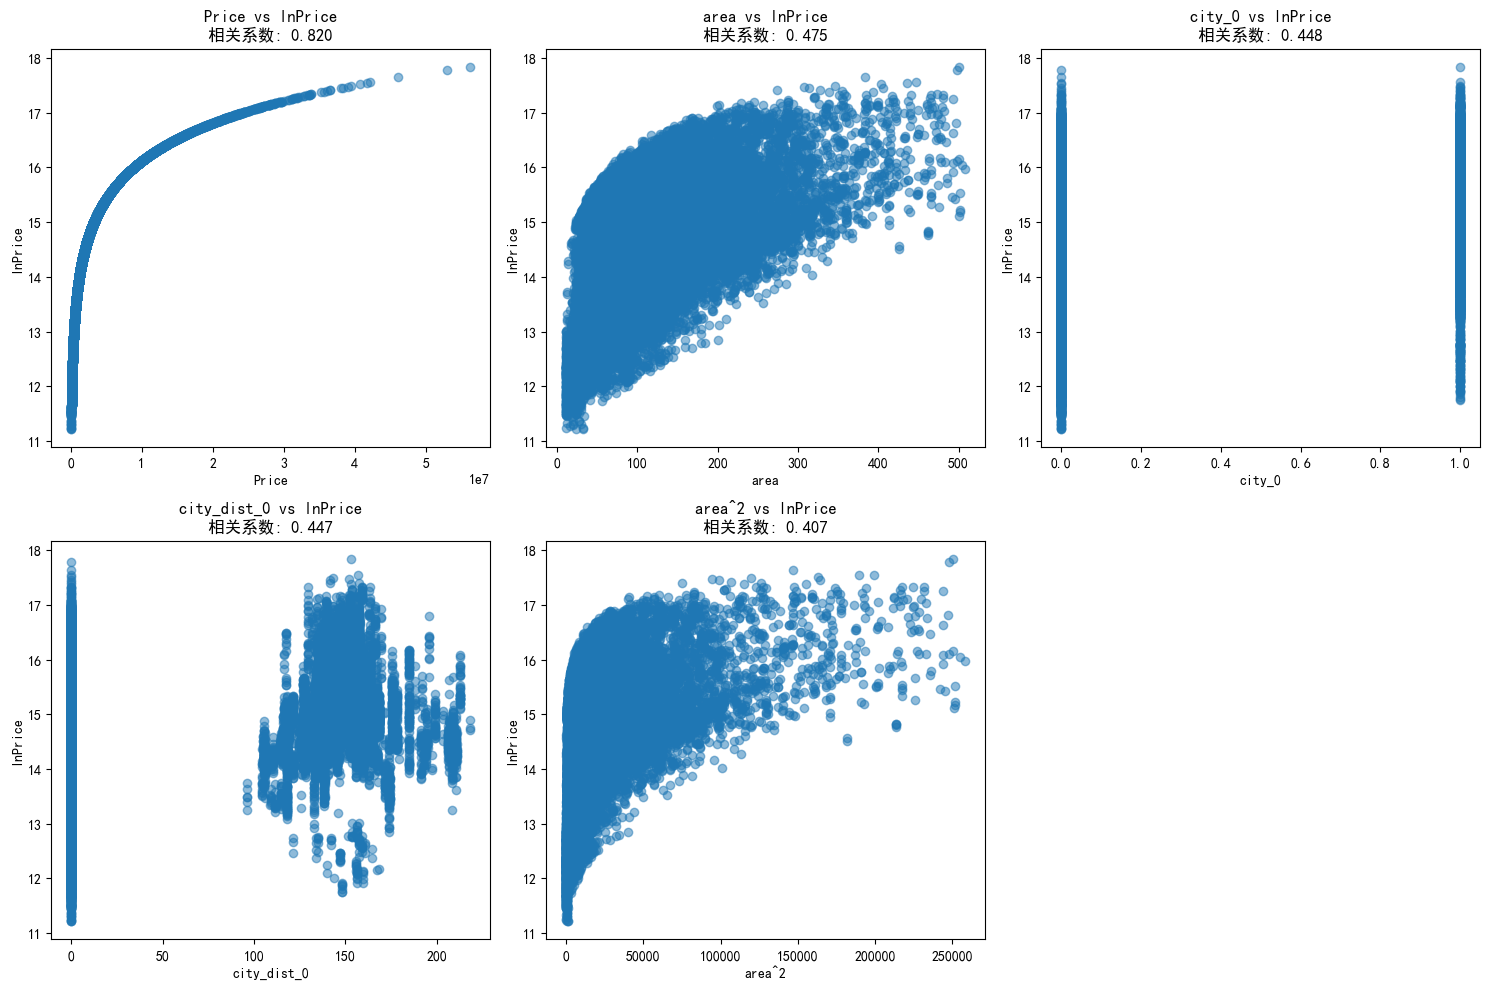

In [44]:
# 1.4.3 购房训练集探究自变量与lnPrice的关系

# 计算所有数值变量与lnPrice的相关系数
numeric_cols = df_price_train_final.select_dtypes(include=[np.number]).columns.tolist()
correlations = df_price_train_final[numeric_cols].corr()['lnPrice'].abs().sort_values(ascending=False)

print("购房训练集变量与lnPrice的相关系数（绝对值）:")
for var, corr in correlations.items():
    if var != 'lnPrice' and corr > 0.1:
        print(f"{var}: {corr:.3f}")

# 选择与lnPrice相关性最高的变量绘制散点图
top_vars = correlations[1:6].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(top_vars):
    if i < len(axes):
        axes[i].scatter(df_price_train_final[var], df_price_train_final['lnPrice'], alpha=0.5)
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('lnPrice')
        axes[i].set_title(f'{var} vs lnPrice\n相关系数: {correlations[var]:.3f}')

for i in range(len(top_vars), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [45]:
# 1.4.4 保存购房训练集最终数据集
df_price_train_final.to_csv("house_price_train_dataset.csv", index=False)
print("购房训练集最终数据集已保存为 house_price_train_dataset.csv")
print(f"数据集形状: {df_price_train_final.shape}")

购房训练集最终数据集已保存为 house_price_train_dataset.csv
数据集形状: (103871, 88)
